In [1]:
from importlib import reload
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import einops

import dinov2

In [2]:
import ray
runtime_env = {
    "conda": "autopath",
}
ray.init(runtime_env=runtime_env, num_cpus=24)
assert ray.is_initialized()

/home/t-9dkarp/miniconda3/envs/autopath/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-07 09:42:03,043	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-08-07 09:42:04,927	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


In [44]:
import autopath.gigaq.dinov2.augmentations
reload(autopath.gigaq.dinov2.augmentations)
import autopath.gigaq.dinov2.dataset
reload(autopath.gigaq.dinov2.dataset)
import autopath.gigaq.dinov2.dataloader
reload(autopath.gigaq.dinov2.dataloader)

<module 'autopath.gigaq.dinov2.dataloader' from '/home/t-9dkarp/autopath/autopath/gigaq/dinov2/dataloader.py'>

# DATASET

In [45]:
databatch = autopath.gigaq.dinov2.dataset.make_databatch(verbose=True, debug=True)

In [46]:
databatch.journal()

,hash,uuid,version,event,tag,datetime
14,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,82e789e6-7a52-4a9a-83b0-8e69a9da8677,None,build:end,None,2025-08-07-02:40:10.194077
8,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,82e789e6-7a52-4a9a-83b0-8e69a9da8677,None,build:start,None,2025-08-07-00:44:29.372664
15,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,6d128b5f-53a2-4c38-bd01-953756b558fa,None,build:start,None,2025-08-07-00:18:52.003039
5,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,ff355fee-0c12-426e-b9c0-5772c7b66fc8,None,build:start,None,2025-08-07-00:14:05.483281
18,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,c9b310cd-d536-4b65-8336-6ca2b6c25185,None,build:start,None,2025-08-07-00:12:13.805827
0,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,f3302014-ffad-43b3-873e-8f7221ac646b,None,build:start,None,2025-08-07-00:10:09.413390
16,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,39dbbce8-ebfc-4e95-ae50-f0bbd8868456,None,build:start,None,2025-08-07-00:08:24.178892
7,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,bfee12e5-f770-417c-bf14-b48538873019,None,build:start,None,2025-08-07-00:00:49.614903
9,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,01ca116c-9897-424f-8a05-98fb3103e6e3,None,build:start,None,2025-08-06-23:53:36.541619
3,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...,855f479e-0b82-4340-9272-6d164496144f,None,build:start,None,2025-08-06-23:52:08.441546


In [47]:
databatch.scopes()

,source,resolution,train_fraction,randomize,seed,version,hash
0,/mnt/labshare/SLIDES/CPTAC_downloads,256px_256um,0.8,False,42,None,3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec...
1,/mnt/labshare/SLIDES/CPTAC_downloads,256x256,0.8,False,42,None,f7e8181738809db0b81b305a9de31e1687624b072419ed...


In [50]:
shard0 = databatch.datablocks()[0].read('train')
shard0.shape

torch.Size([526, 3, 256, 256])

In [52]:
lens = databatch.lens('train')

In [53]:
lens[773:776]

[1076, 156, 638]

In [54]:
dataset = autopath.gigaq.dinov2.dataset.make_dataset(verbose=True, debug=True)

DEBUG: autopath.gigaq.dinov2.dataset.GigapathDatabatch: path /mnt/labshare/PROJECTS/GIGAPATH_UQ/dbx/autopath.gigaq.dinov2.dataset.GigapathDatabatch/#/3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec2c88bb4bfc071a9903/train/train.npy valid: True
DEBUG: autopath.gigaq.dinov2.dataset.GigapathDatabatch: path /mnt/labshare/PROJECTS/GIGAPATH_UQ/dbx/autopath.gigaq.dinov2.dataset.GigapathDatabatch/#/3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec2c88bb4bfc071a9903/test/test.npy valid: True
VERBOSE: autopath.gigaq.dinov2.dataset.GigapathDatabatch: Skipping existing datablock: /mnt/labshare/PROJECTS/GIGAPATH_UQ/dbx/autopath.gigaq.dinov2.dataset.GigapathDatabatch/#/3db2a81c169e90ec86dcb1fcd6b40113c83f18fa6362ec2c88bb4bfc071a9903
DEBUG: make_dataset: self._n_shards=3692, self._shard_bounds=array([    526,    2371,    2599, ..., 3622773, 3623009, 3623338])


In [55]:
len(dataset)

3623338

In [26]:
sample0, _ = dataset[0]

DEBUG: make_dataset: __getitem__: index=0, shard_idx=0, shard_lo=0, shard_len=526, shard_hi=526,idx=0


In [27]:
sample0.keys()

dict_keys(['global_crops', 'global_crops_teacher', 'local_crops', 'offsets'])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


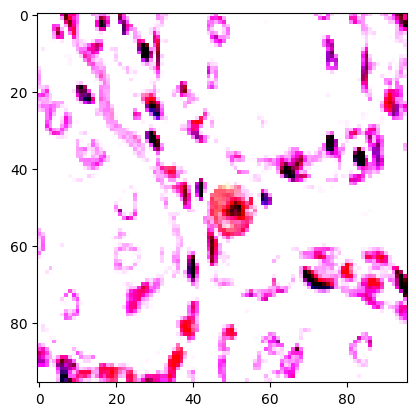

In [60]:
%matplotlib inline
lc00 = sample0['local_crops'][0]
plt.imshow(einops.rearrange(lc00, 'c h w -> h w c'))

In [61]:
display(databatch.lens('train')[774])

156

In [62]:
display(databatch.datablocks()[774].size('train'))

156

In [63]:
dataset[768008]

DEBUG: make_dataset: __getitem__: index=768008, shard_idx=604, shard_lo=764134, shard_len=5624, shard_hi=769758, idx=3874


({'global_crops': [tensor([[[ 1.1872,  1.5639,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
            [ 1.0331,  1.6324,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
            [ 0.8789,  1.5639,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
            ...,
            [ 2.2489,  2.2489,  2.2489,  ...,  0.8789,  0.6221,  0.7248],
            [ 2.2489,  2.2489,  2.2489,  ...,  0.8789,  1.1187,  1.7523],
            [ 2.2489,  2.2489,  2.2489,  ...,  0.9474,  1.6324,  2.2489]],
   
           [[-0.7052, -0.2150,  1.3431,  ...,  2.2535,  1.9034,  0.6954],
            [-0.7927, -0.0749,  1.2556,  ...,  2.4286,  1.4657,  0.9405],
            [-0.8452, -0.0924,  1.1856,  ...,  2.4286,  1.5182,  1.3957],
            ...,
            [ 2.4286,  2.4286,  2.4286,  ..., -0.5476, -0.7402, -0.6527],
            [ 2.4286,  2.4286,  2.4286,  ..., -0.6527, -0.3901,  0.2402],
            [ 2.4286,  2.4286,  2.4286,  ..., -0.7227, -0.0049,  1.3431]],
   
           [[ 0.9668,  1.3677,  2.6400,  ...,  2.640

# DATALOADER

In [64]:
import autopath.gigaq.dinov2.dataloader
reload(autopath.gigaq.dinov2.dataloader)

<module 'autopath.gigaq.dinov2.dataloader' from '/home/t-9dkarp/autopath/autopath/gigaq/dinov2/dataloader.py'>

In [65]:
dataloader = autopath.gigaq.dinov2.dataloader.make_dataloader(dataset, batch_size=8)

infinite data loader


In [66]:
try:
    display(len(dataloader))
except: 
    display(None)

None

In [67]:
import time
N = 10
for i, sample in enumerate(dataloader):
    if i >= N:
        break
    print(f"{i}-th sample")
    time.sleep(1)
print("Done")

DEBUG: make_dataset: __getitem__: index=768008, shard_idx=604, shard_lo=764134, shard_len=5624, shard_hi=769758, idx=3874
DEBUG: make_dataset: __getitem__: index=1208722, shard_idx=1261, shard_lo=1208217, shard_len=808, shard_hi=1209025, idx=505
DEBUG: make_dataset: __getitem__: index=944756, shard_idx=826, shard_lo=944108, shard_len=777, shard_hi=944885, idx=648
DEBUG: make_dataset: __getitem__: index=3480942, shard_idx=3521, shard_lo=3480525, shard_len=1382, shard_hi=3481907, idx=417
DEBUG: make_dataset: __getitem__: index=3322525, shard_idx=3373, shard_lo=3321457, shard_len=2297, shard_hi=3323754, idx=1068
DEBUG: make_dataset: __getitem__: index=2726010, shard_idx=2812, shard_lo=2725664, shard_len=1684, shard_hi=2727348, idx=346
DEBUG: make_dataset: __getitem__: index=1574991, shard_idx=1929, shard_lo=1573274, shard_len=2884, shard_hi=1576158, idx=1717
DEBUG: make_dataset: __getitem__: index=2687834, shard_idx=2775, shard_lo=2687551, shard_len=548, shard_hi=2688099, idx=283
DEBUG: m

In [68]:
def unnorm(t):
    return ((t-t.min())/(t.max()-t.min())*255).byte()

In [69]:
dl0 = next(iter(dataloader))

DEBUG: make_dataset: __getitem__: index=768008, shard_idx=604, shard_lo=764134, shard_len=5624, shard_hi=769758, idx=3874
DEBUG: make_dataset: __getitem__: index=1208722, shard_idx=1261, shard_lo=1208217, shard_len=808, shard_hi=1209025, idx=505
DEBUG: make_dataset: __getitem__: index=944756, shard_idx=826, shard_lo=944108, shard_len=777, shard_hi=944885, idx=648
DEBUG: make_dataset: __getitem__: index=3480942, shard_idx=3521, shard_lo=3480525, shard_len=1382, shard_hi=3481907, idx=417
DEBUG: make_dataset: __getitem__: index=3322525, shard_idx=3373, shard_lo=3321457, shard_len=2297, shard_hi=3323754, idx=1068
DEBUG: make_dataset: __getitem__: index=2726010, shard_idx=2812, shard_lo=2725664, shard_len=1684, shard_hi=2727348, idx=346
DEBUG: make_dataset: __getitem__: index=1574991, shard_idx=1929, shard_lo=1573274, shard_len=2884, shard_hi=1576158, idx=1717
DEBUG: make_dataset: __getitem__: index=2687834, shard_idx=2775, shard_lo=2687551, shard_len=548, shard_hi=2688099, idx=283
DEBUG: m

In [70]:
dl0.keys()

dict_keys(['collated_global_crops', 'collated_local_crops', 'collated_masks', 'mask_indices_list', 'masks_weight', 'upperbound', 'n_masked_patches'])

In [71]:
cgc0 = dl0['collated_global_crops']
display(len(cgc0))
display(cgc0[0].shape)
display(cgc0[0].dtype)

16

torch.Size([3, 224, 224])

torch.float16

In [72]:
ucgc0 = unnorm(cgc0)
display(ucgc0.shape)
display(ucgc0.dtype)

torch.Size([16, 3, 224, 224])

torch.uint8

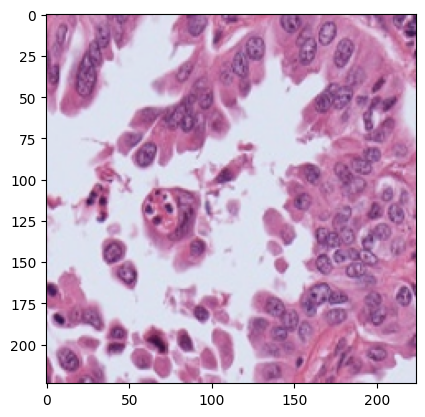

In [73]:
%matplotlib inline
plt.imshow(einops.rearrange(ucgc0[0], 'c h w -> h w c').numpy())